In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
golf = pd.read_csv("ASA All PGA Raw Data - Tourn Level.csv")
golf = golf[golf['no_cut'] == 0]

In [3]:
golf.info

<bound method DataFrame.info of       Player_initial_last  tournament id  player id  hole_par  strokes  \
0                A. Ancer      401353224       9261       288      289   
1               A. Hadwin      401353224       5548       288      286   
2               A. Lahiri      401353224       4989       144      147   
3                 A. Long      401353224       6015       144      151   
4                A. Noren      401353224       3832       144      148   
...                   ...            ...        ...       ...      ...   
36859            V. Singh           2271        392       144      146   
36860              W. Kim           2271       7082       144      150   
36861           W. McGirt           2271       3532       216      215   
36862            Z. Blair           2271       9040       288      278   
36863           Z. Sucher           2271       4708       144      147   

       hole_DKP  hole_FDP  hole_SDP  streak_DKP  streak_FDP  ...  purse  \
0   

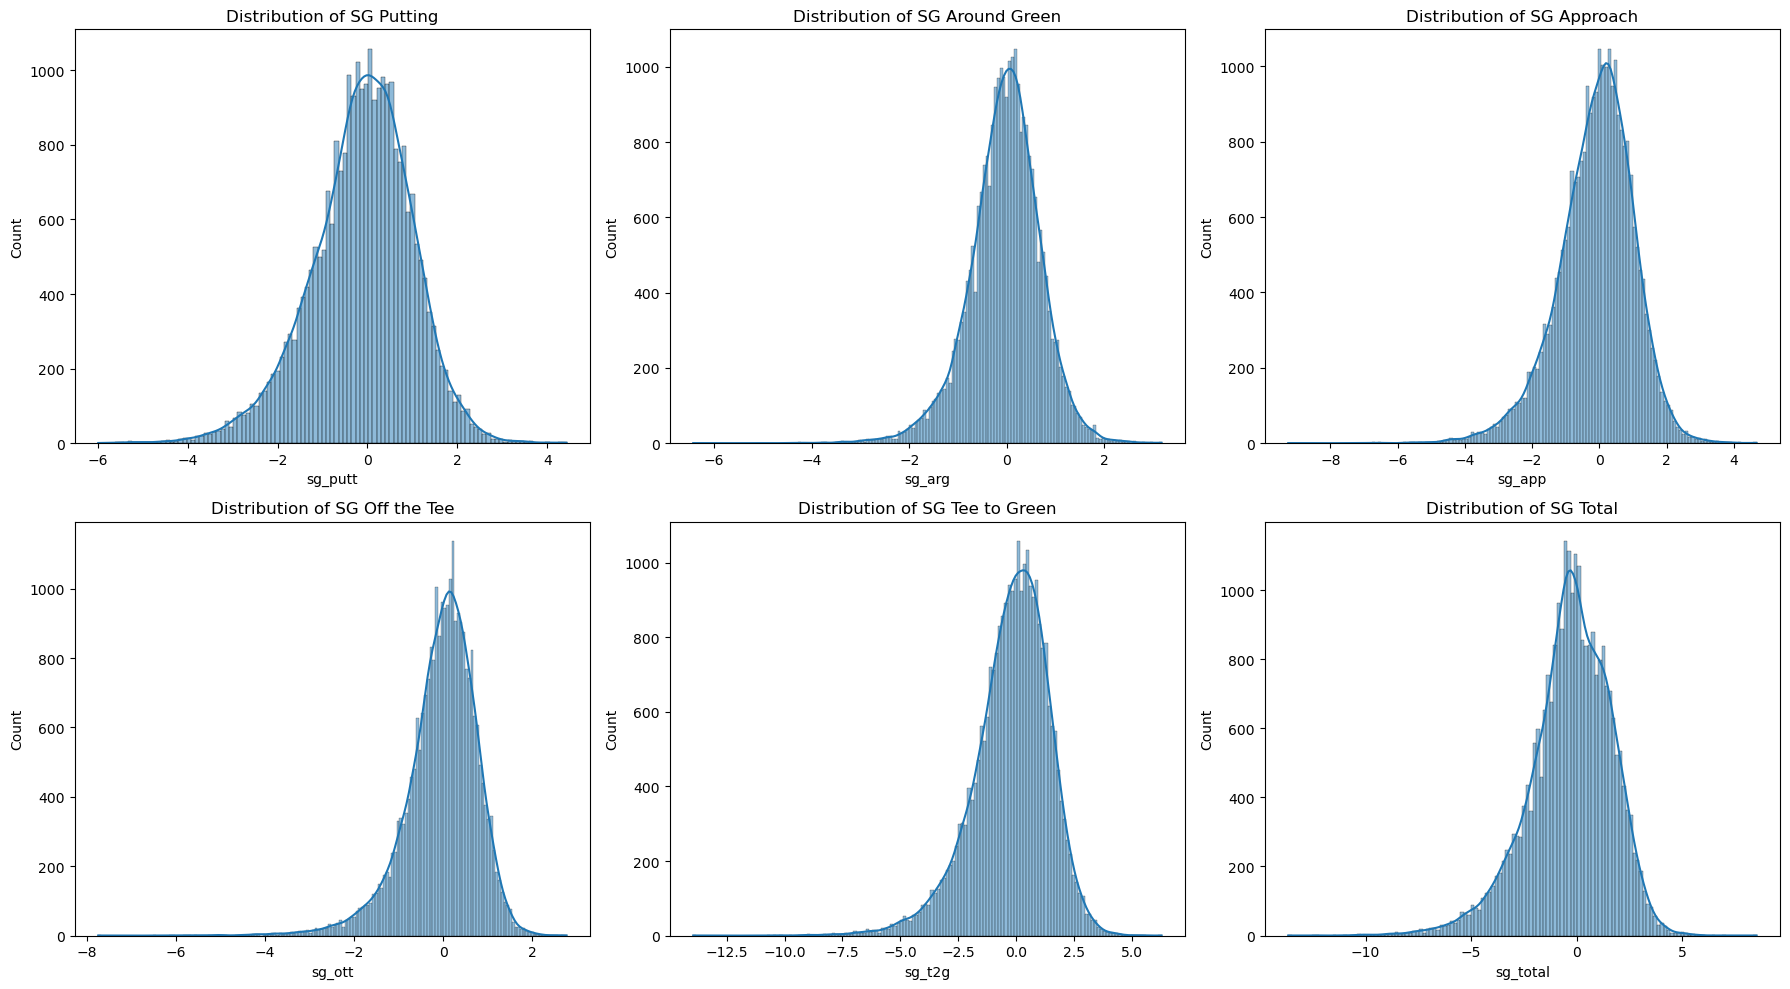

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(golf['sg_putt'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of SG Putting')

sns.histplot(golf['sg_arg'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of SG Around Green')

sns.histplot(golf['sg_app'], kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Distribution of SG Approach')

sns.histplot(golf['sg_ott'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of SG Off the Tee')

sns.histplot(golf['sg_t2g'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of SG Tee to Green')

sns.histplot(golf['sg_total'], kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Distribution of SG Total')

plt.tight_layout()
plt.show()

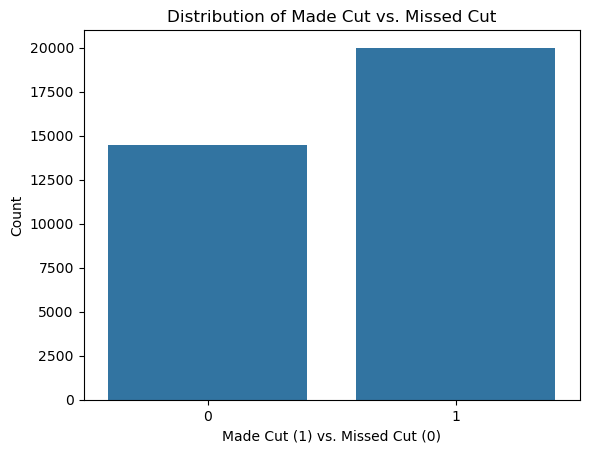

In [5]:
sns.countplot(x=golf['made_cut'])
plt.title('Distribution of Made Cut vs. Missed Cut')
plt.xlabel('Made Cut (1) vs. Missed Cut (0)')
plt.ylabel('Count')
plt.show()

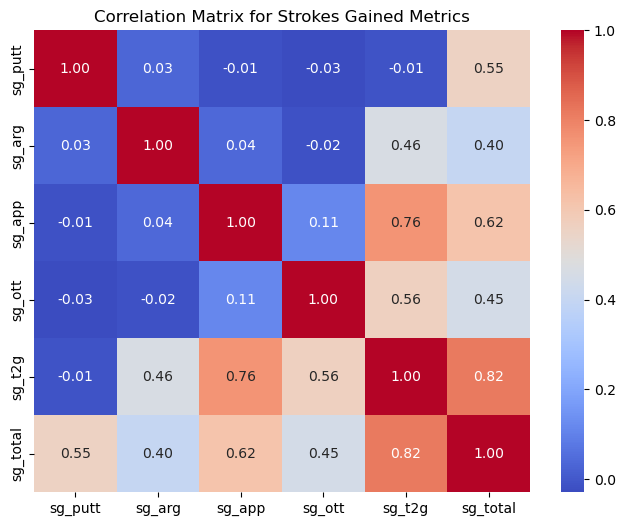

In [6]:
# Correlation matrix for the strokes gained metrics
correlation_matrix = golf[['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']].corr()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Strokes Gained Metrics')
plt.show()

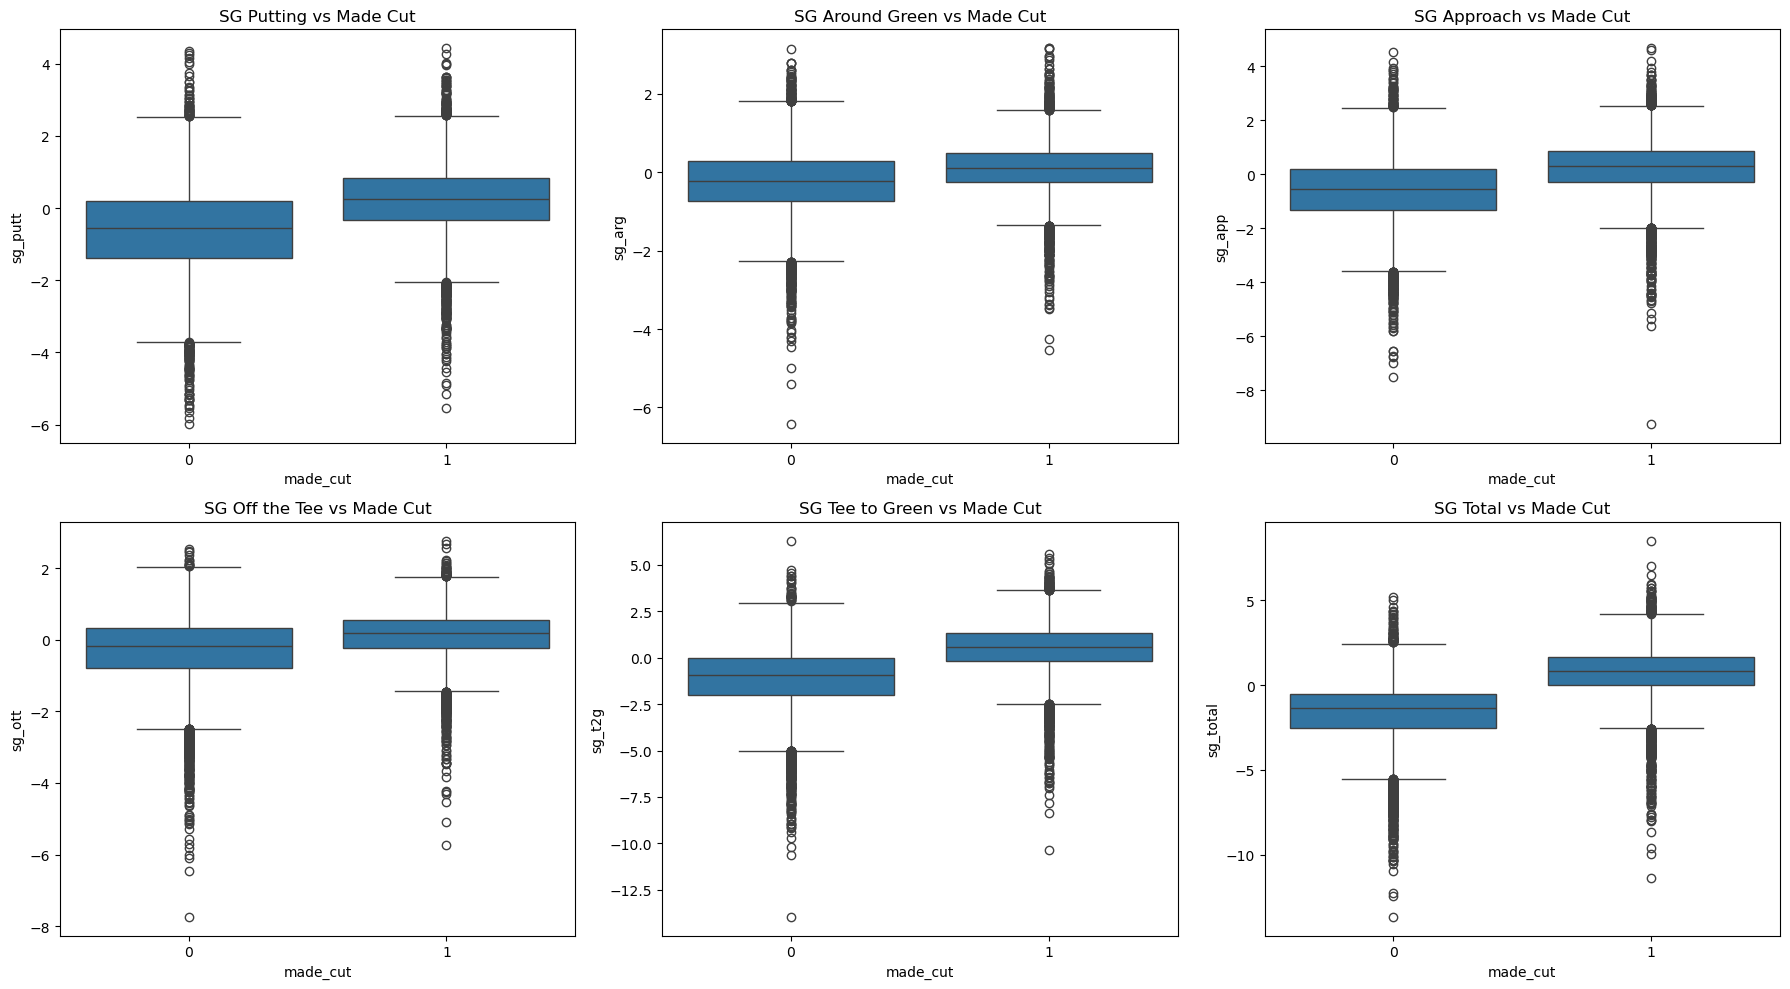

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(x=golf['made_cut'], y=golf['sg_putt'], ax=axes[0, 0])
axes[0, 0].set_title('SG Putting vs Made Cut')

sns.boxplot(x=golf['made_cut'], y=golf['sg_arg'], ax=axes[0, 1])
axes[0, 1].set_title('SG Around Green vs Made Cut')

sns.boxplot(x=golf['made_cut'], y=golf['sg_app'], ax=axes[0, 2])
axes[0, 2].set_title('SG Approach vs Made Cut')

sns.boxplot(x=golf['made_cut'], y=golf['sg_ott'], ax=axes[1, 0])
axes[1, 0].set_title('SG Off the Tee vs Made Cut')

sns.boxplot(x=golf['made_cut'], y=golf['sg_t2g'], ax=axes[1, 1])
axes[1, 1].set_title('SG Tee to Green vs Made Cut')

sns.boxplot(x=golf['made_cut'], y=golf['sg_total'], ax=axes[1, 2])
axes[1, 2].set_title('SG Total vs Made Cut')

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import ttest_ind

made_cut = golf[golf['made_cut'] == 1]
missed_cut = golf[golf['made_cut'] == 0]
# Clean the data by dropping the NAs
made_cut = made_cut.dropna(subset=['sg_total'])
missed_cut = missed_cut.dropna(subset=['sg_total'])
t_stat, p_value = ttest_ind(made_cut['sg_total'], missed_cut['sg_total'])

print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

T-statistic: 131.9584930630811
P-value: 0.0


In [9]:
made_cut = made_cut.dropna(subset=['sg_total'])
missed_cut = missed_cut.dropna(subset=['sg_total'])

In [10]:
print(made_cut['sg_total'].isna().sum())  # Missing values in players who made the cut
print(missed_cut['sg_total'].isna().sum())  # Missing values in players who missed the cut

0
0


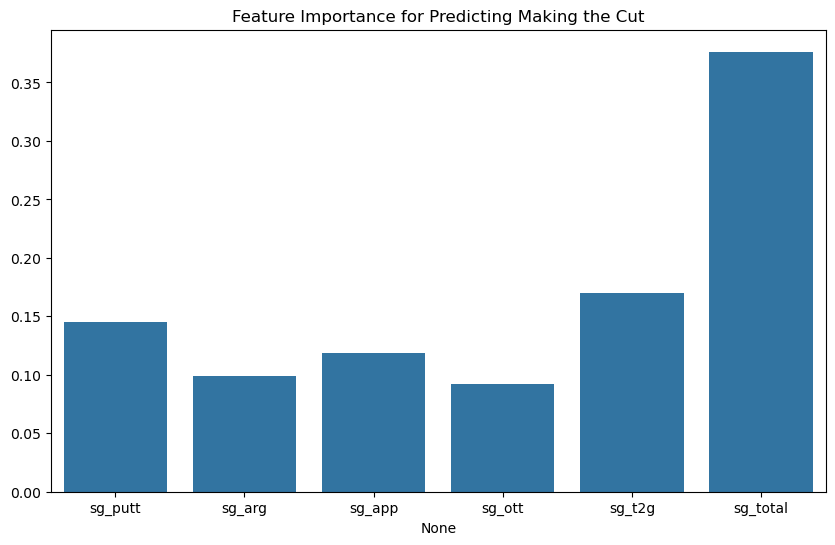

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Prepare the features and target as X and Y
X = golf[['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']]
y = golf['made_cut']

# Initialize and fit the random forest
model = RandomForestClassifier(n_estimators=100)
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=feature_importances)
plt.title('Feature Importance for Predicting Making the Cut')
plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

golf = golf.dropna(subset=['made_cut'])

X = golf[['sg_putt', 'sg_total']]  # Using only putting and sg_total as features
y = golf['made_cut']  # The target variable

# Handle missing values in features (if there are any)
imputer = SimpleImputer(strategy='mean')  # Using mean to fill missing values
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split data into training and test sets for training and evaluating the models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

logreg = LogisticRegression()

# Train the model
logreg.fit(X_train, y_train)

# Make some predictions
y_pred = logreg.predict(X_test)

# Evaluate the model
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7775681950087058
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.60      0.69      2882
           1       0.76      0.90      0.83      4010

    accuracy                           0.78      6892
   macro avg       0.79      0.75      0.76      6892
weighted avg       0.78      0.78      0.77      6892

Confusion Matrix:
[[1742 1140]
 [ 393 3617]]


In [29]:
# Lets see if XGB can give us some better results
import xgboost as xgb

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Now with the trained model make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb)}')
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7917875798026698
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      2882
           1       0.80      0.85      0.83      4010

    accuracy                           0.79      6892
   macro avg       0.79      0.78      0.78      6892
weighted avg       0.79      0.79      0.79      6892

Confusion Matrix:
[[2047  835]
 [ 600 3410]]


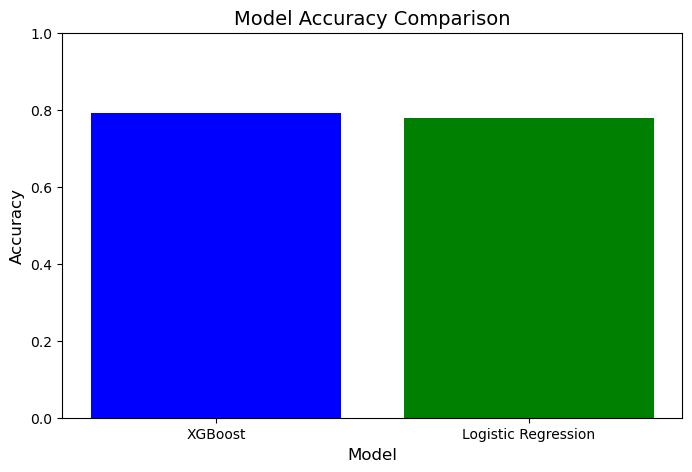

In [37]:
from sklearn.metrics import accuracy_score
# I wnt to compare the models I made with accuracy scores 
# Make predictions with both models
y_pred_xgb = xgb_model.predict(X_test)
y_pred_logreg = logreg.predict(X_test)

# Now calculate accuracy for both models
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

models = ['XGBoost', 'Logistic Regression']
accuracies = [accuracy_xgb, accuracy_logreg]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1])  
plt.show()

In [33]:
# Lets now try to use the trained model to predict whether a new player will make the cut 
# using some example input called new_data
new_data = pd.DataFrame({'sg_putt': [0.5], 'sg_total': [1.2]})  
prediction = xgb_model.predict(new_data)  

# Output prediction (1 = made the cut, 0 = missed the cut)
print(f'Made the cut: {prediction[0]}')

Made the cut: 1
